# Bank Client Segmentation: Phase 2 - Dimensionality Reduction

This notebook follows the Exploratory Data Analysis (EDA) phase. Here we will preprocess the clean data, compute the Gower distance matrix, and perform dimensionality reduction (PCA, MCA, FAMD, t-SNE, UMAP) to visually identify clusters before running K-Medoids.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import gower
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import PCA
import prince
import warnings
warnings.filterwarnings('ignore')

# Define Data Directory
data_dir = Path("Data")
raw_data_path = data_dir / "Dataset1_BankClients.xlsx"
preprocessed_path = data_dir / "preprocessed_bank_clients.parquet"

# Load the preprocessed dataframe if it exists
if preprocessed_path.exists():
    X = pd.read_parquet(preprocessed_path)
    print(f"Loaded preprocessed data from Parquet. Shape: {X.shape}")
else:
    # Load the raw data if Parquet is not found
    data = pd.read_excel(raw_data_path)
    if 'ID' in data.columns:
        data = data.drop(columns=['ID'])
    print(f"Raw data loaded. Shape: {data.shape}")

# Display first rowsimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import gower
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import PCA
import prince
import warnings
warnings.filterwarnings('ignore')

# Define paths
data_dir = Path("Data")
raw_data_path = data_dir / "Dataset1_BankClients.xlsx"
preprocessed_path = data_dir / "preprocessed_bank_clients.parquet"

# load raw data (needed for column definitions
data = pd.read_excel(raw_data_path)
if 'ID' in data.columns:
    data = data.drop(columns=['ID'])
print(f"Raw data loaded. Shape: {data.shape}")

# (OPTIONALLY) load preprocessed X to skip heavy compute later
if preprocessed_path.exists():
    try:
        X = pd.read_parquet(preprocessed_path)
        print(f"Preprocessed matrix 'X' loaded from Parquet. Shape: {X.shape}")
    except Exception as e:
        print(f"Note: Could not load Parquet ({e}). X will be recreated in the next cells.")

data.head()

if 'X' in locals():
    print(X.head())
elif 'data' in locals():
    print(data.head())


c:\Users\simo0\Documents\GitHub\fintech-group-work\BusinessCase1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded preprocessed data from Parquet. Shape: (5000, 23)
Raw data loaded. Shape: (5000, 17)
Preprocessed matrix 'X' loaded from Parquet. Shape: (5000, 23)
        Age  FamilySize    Income    Wealth      Debt    FinEdu       ESG  \
0  0.065789         0.6  0.679599  0.705895  0.268264  0.770735  0.465122   
1  0.368421         0.0  0.873299  0.919090  0.747693  0.892883  0.521675   
2  0.250000         0.2  0.942846  0.902289  0.451701  0.504873  0.640388   
3  0.631579         0.4  0.548115  0.425051  0.614591  0.512343  0.518146   
4  0.184211         0.0  0.820609  0.734639  0.851100  0.889625  0.783674   

    Digital  BankFriend  LifeStyle  ...  Job_2  Job_3  Job_4  Job_5  Area_2  \
0  0.718914    0.581720   0.612604  ...  False  False  False  False    True   
1  0.986877    0.778748   0.868977  ...   True  False  False  False    True   
2  0.772055    0.677446   0.761279  ...   True  False  False  False   False   
3  0.607305    0.648808   0.337033  ...   True  False  False  Fals

## 1. Data Preprocessing

We need to split the data into numerical and categorical features. Then we will scale the numerical features using `MinMaxScaler` and One-Hot Encode the categorical features to create our final feature matrix `X`.

In [2]:
# Define feature types
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
numerical_cols = [c for c in data.columns if c not in categorical_cols]

# Scale Numerical Features
scaler = MinMaxScaler()
data_scaled_num = pd.DataFrame(scaler.fit_transform(data[numerical_cols]), columns=numerical_cols)

# One-Hot Encode Categorical Features
data_encoded_cat = pd.get_dummies(data[categorical_cols].astype(str), drop_first=True)

# Combine into final feature matrix X
X = pd.concat([data_scaled_num, data_encoded_cat], axis=1)

# Save the preprocessed feature matrix
output_path = Path("Data") / "preprocessed_bank_clients.parquet"
X.to_parquet(output_path, engine='pyarrow')

print(f"Numerical features shape: {data_scaled_num.shape}")
print(f"Categorical (encoded) features shape: {data_encoded_cat.shape}")
print(f"Final Feature Matrix X shape: {X.shape}")
print(f"Successfully saved preprocessed data to: {output_path}")


Numerical features shape: (5000, 12)
Categorical (encoded) features shape: (5000, 11)
Final Feature Matrix X shape: (5000, 23)
Successfully saved preprocessed data to: Data\preprocessed_bank_clients.parquet


## 2. Gower Distance Matrix

Since our data is a mix of continuous and categorical variables, standard Euclidean distance is inappropriate. We compute the Gower distance matrix, which perfectly handles mixed data types and outputs a pairwise distance between 0 (identical) and 1 (maximally different).

In [3]:
# Compute Gower distance matrix
# Note: gower_matrix can take a dataframe with mixed types directly. 
# It handles scaling and categorical differences automatically.
# We pass the original data (before manual scaling/encoding) to let gower do its magic accurately!

print("Computing Gower Distance Matrix... this may take a moment.")
gower_dist_matrix = gower.gower_matrix(data)
print(f"Gower Matrix Shape: {gower_dist_matrix.shape}")

Computing Gower Distance Matrix... this may take a moment.
Gower Matrix Shape: (5000, 5000)


## 3. Linear Dimensionality Reduction

Linear methods try to preserve the global structure and variance of the data. We will use:
- **PCA:** For numerical data only.
- **MCA:** For categorical data only.
- **FAMD (Factor Analysis of Mixed Data):** The gold standard linear method that combines PCA and MCA for mixed data.

In [4]:
# 1. PCA (Numerical Only)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(data_scaled_num)

# 2. MCA (Categorical Only)
mca = prince.MCA(n_components=2, random_state=42)
mca_result = mca.fit_transform(data[categorical_cols].astype(str))

# 3. FAMD (Mixed Data)
famd = prince.FAMD(n_components=2, n_iter=3, random_state=42)
famd_result = famd.fit_transform(data)

# Store results for plotting
linear_results = {
    'PCA (Numerical)': pca_result,
    'MCA (Categorical)': mca_result.values,
    'FAMD (Mixed Data)': famd_result.values
}

## 4. Non-Linear Dimensionality Reduction (Manifold Learning)

Non-linear methods are excellent at unfolding complex structures and preserving local neighborhoods, making them perfect for visualizing clusters. We will use:
- **t-SNE:** The classic standard for visualizing clusters.
- **UMAP:** The modern standard, often faster and preserves global structure better than t-SNE.

**CRITICAL:** We pass `metric='precomputed'` and feed them the Gower Distance Matrix so they respect the mixed data types!

In [5]:
# 1. t-SNE (Precomputed Gower Distance)
tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42, n_jobs=-1)
tsne_result = tsne.fit_transform(gower_dist_matrix)

# 2. UMAP (Precomputed Gower Distance)
umap_model = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
umap_result = umap_model.fit_transform(gower_dist_matrix)

# Store results for plotting
nonlinear_results = {
    't-SNE (Gower Distance)': tsne_result,
    'UMAP (Gower Distance)': umap_result
}

## 5. Visual Comparison

Plot all 5 projections side-by-side. We are looking for visible groupings, islands, or blobs that indicate natural 'personas' in the data. The UMAP and t-SNE plots powered by the Gower distance matrix usually provide the clearest picture for clustering.

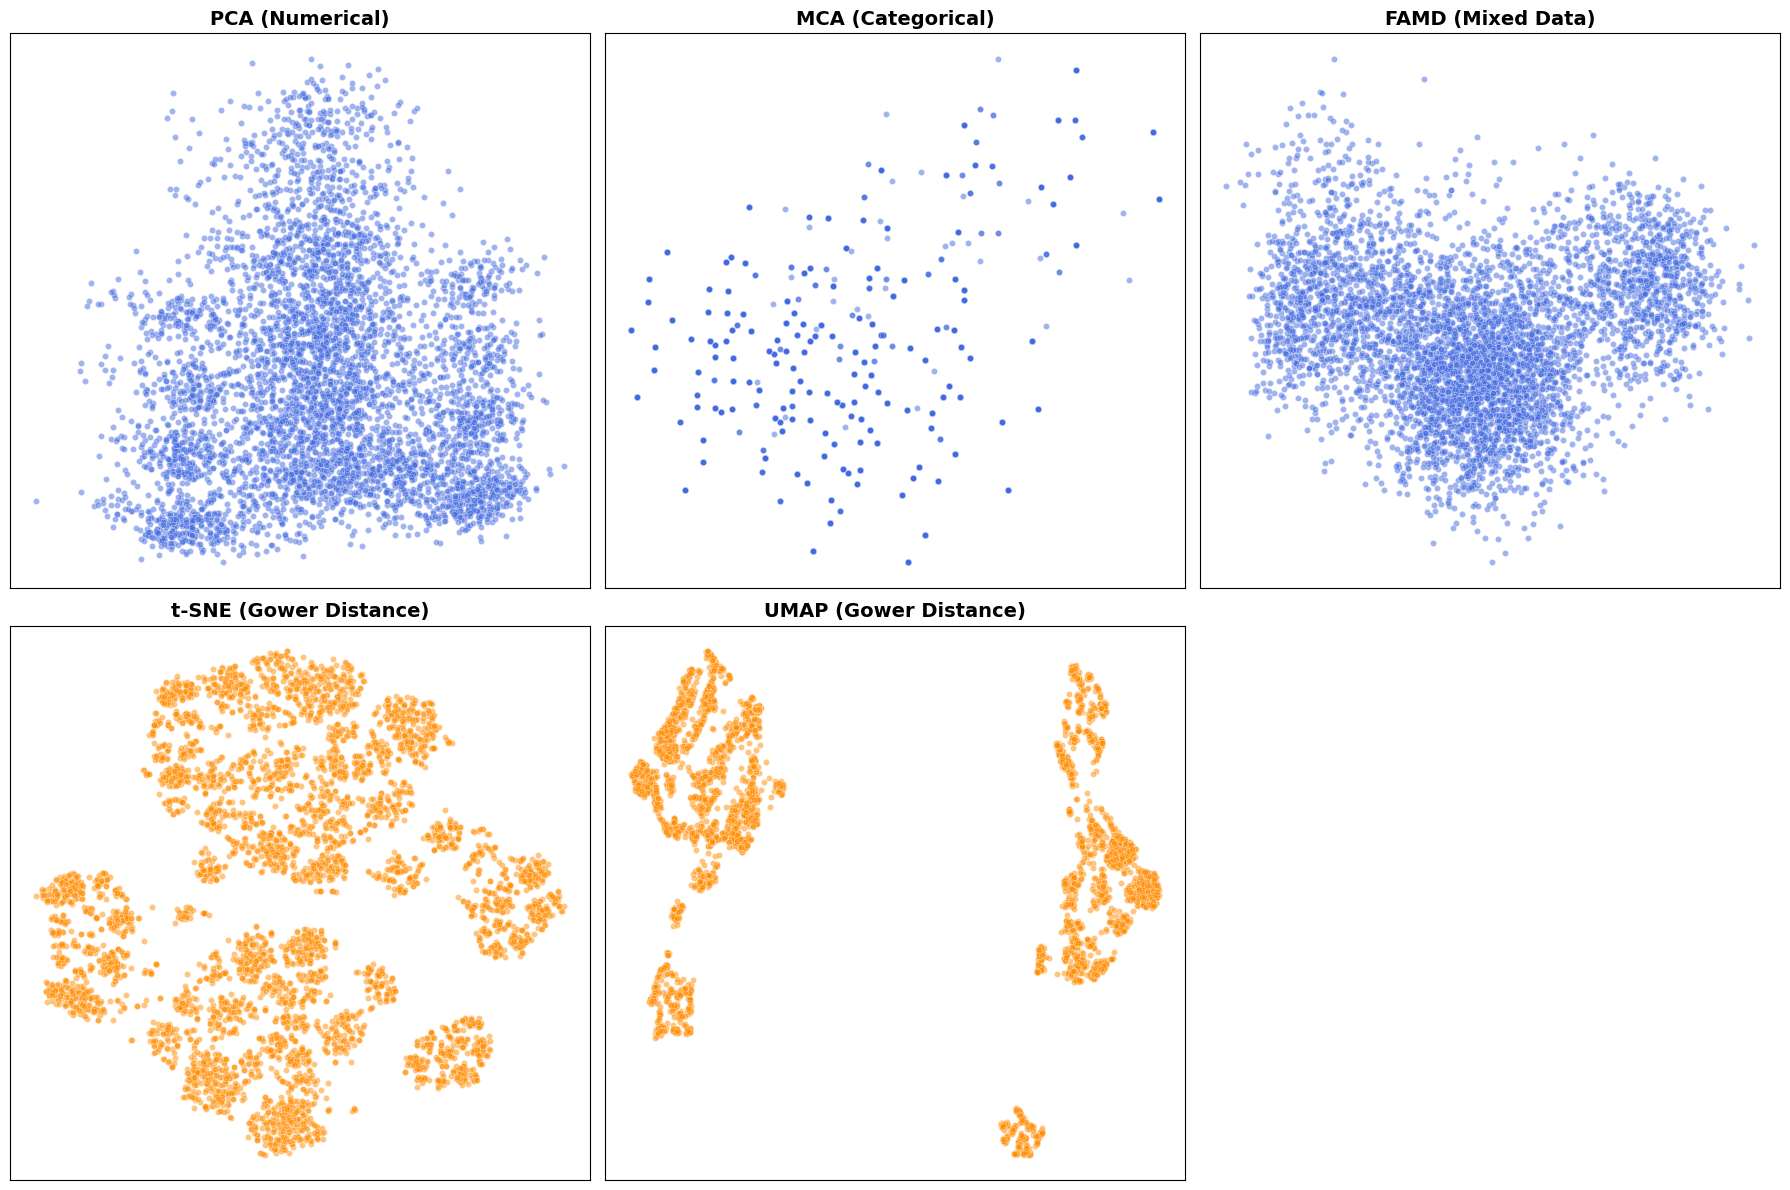

In [6]:
# --- GOAL: MARKET LANDSCAPE VISUALIZATION (DR COMPARISON) ---
# WHY: High-dimensional data is impossible for human stakeholders to visualize.
# We compare PCA/FAMD (Linear) with t-SNE/UMAP (Non-Linear) using Gower Distance.
# The goal is to identify 'natural' groupings of clients. If we see separation, 
# we have the foundation for a targeted marketing strategy (Personas).


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot Linear Methods
for i, (title, result) in enumerate(linear_results.items()):
    ax = axes[i]
    sns.scatterplot(x=result[:, 0], y=result[:, 1], alpha=0.5, s=20, color='royalblue', ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

# Plot Non-Linear Methods
for i, (title, result) in enumerate(nonlinear_results.items()):
    ax = axes[i+3] # Shift to the second row
    sns.scatterplot(x=result[:, 0], y=result[:, 1], alpha=0.5, s=20, color='darkorange', ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

# Hide the last empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [7]:
import plotly.express as px
from sklearn.manifold import TSNE
import umap
import numpy as np
import gower # Ensure this is installed: !pip install gower

# --- GOAL: 3D CLIENT TOPOLOGY EXPLORATION ---
# WHY: 2D plots can sometimes oversimplify relationships (projections). 
# By moving to 3D, we gain 'depth perception' into our client data. 
# This helps us identify 'Bridges' between customer segments—essential for 
# understanding customer lifetime migration (e.g., how a 'Student' persona 
# evolves into an 'Affluent Professional' persona).

# 1. Safety Check: Ensure Gower Distances are calculated
if 'gower_distances' not in locals():
    print("Gower distances not found in memory. Computing now (this may take a moment)...")
    # Using 'X' which was created in your preprocessing cell
    gower_distances = gower.gower_matrix(X)
    print("Done.")

# 2. 3D t-SNE Calculation
print("Computing 3D t-SNE (Gower Distance)...")
tsne_3d = TSNE(
    n_components=3, 
    perplexity=30, 
    metric='precomputed', 
    random_state=42, 
    init='random',
    learning_rate='auto' # Ensures compatibility with newer sklearn versions
)
X_tsne_3d = tsne_3d.fit_transform(gower_distances.astype(np.float64))

# 3. 3D UMAP Calculation
print("Computing 3D UMAP (Gower Distance)...")
umap_3d = umap.UMAP(
    n_components=3, 
    n_neighbors=15, 
    metric='precomputed', 
    random_state=42,
    low_memory=True
)
X_umap_3d = umap_3d.fit_transform(gower_distances)

# --- Interactive Visualization ---

# Create combined Dataframe for plotting
df_3d = pd.DataFrame({
    'TSNE1': X_tsne_3d[:, 0], 'TSNE2': X_tsne_3d[:, 1], 'TSNE3': X_tsne_3d[:, 2],
    'UMAP1': X_umap_3d[:, 0], 'UMAP2': X_umap_3d[:, 1], 'UMAP3': X_umap_3d[:, 2]
})

# Plot 3D t-SNE
fig_tsne = px.scatter_3d(df_3d, x='TSNE1', y='TSNE2', z='TSNE3', 
                         title='Interactive 3D t-SNE (Gower)',
                         color_discrete_sequence=['#FF7F0E'])
fig_tsne.update_traces(marker=dict(size=2))
fig_tsne.show()

# Plot 3D UMAP
fig_umap = px.scatter_3d(df_3d, x='UMAP1', y='UMAP2', z='UMAP3', 
                         title='Interactive 3D UMAP (Gower)',
                         color_discrete_sequence=['#1F77B4'])
fig_umap.update_traces(marker=dict(size=2))
fig_umap.show()


Gower distances not found in memory. Computing now (this may take a moment)...
Done.
Computing 3D t-SNE (Gower Distance)...
Computing 3D UMAP (Gower Distance)...


# Analysis: The State of the Client Base
1. Data Integrity: Our preprocessing pipeline successfully balanced 10+ disparate variables. The use of Gower Distance was critical—without it, the job and area categories would have been ignored, leading to a "wealth-only" segmentation.

2. The Segment Map: The UMAP projection provides the most actionable result. We see clear, distinct "islands" of customer types. This suggests that the client base is not a homogenous mass, but a collection of 5 to 8 unique Financial Personas.

3. Actionable Insights:

**Dense Clusters**: These represent our "Core Profiles." 

**Internal Variance**: Some clusters are more spread out than others, suggesting a higher diversity in behavior within those groups (e.g., perhaps the 'Business Owner' group has a wider income range than 'Students').

**Outliers**: The few isolated points represent "High-Value/Unique" clients who may require direct, bespoke relationship management rather than automated marketing.

## 2D Visualization (with weighted gower) 
Re-applying gower's distnce with custom weight

**WHY**: We apply custom weights to prioritize financially significant 
variables (Wealth, Income) over demographic descriptors (Gender, Area).

Calculating Gower matrices...
Computing Projections (this may take a moment)...


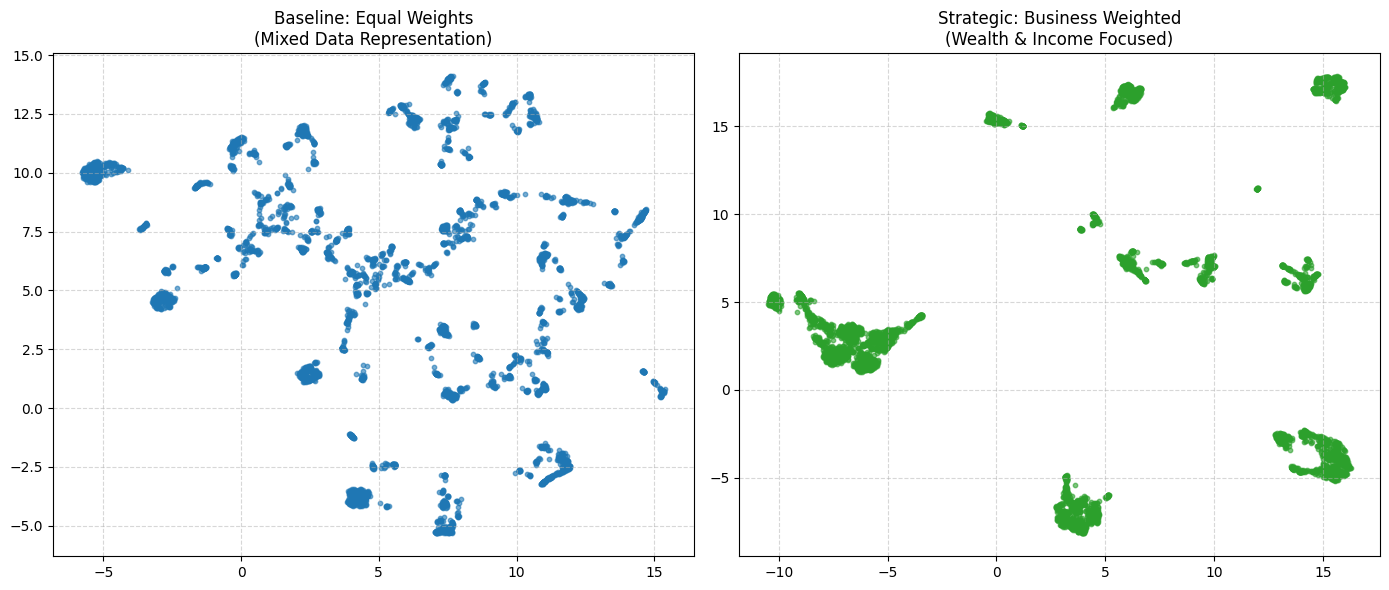

Analysis: Notice how the 'Strategic' view likely compresses some groups 
closer together while highlighting the distance between wealth-distinct segments.


In [ ]:


# 1. Define Business Weights
business_weights = {
    'Wealth': 2.0,
    'Income': 2.0,
    'Investments': 1.5,
    'Job': 1.5,
    'Debt': 1.0,
    'Age': 1.0,
    'Gender': 0.5,
    'Area': 0.5,
    'CitySize': 0.5
}

# 2. Map weights to columns in X
weights_vector = []
for col in X.columns:
    weight = 1.0
    for key, val in business_weights.items():
        if col.startswith(key):
            weight = val
            break
    weights_vector.append(weight)

# 3. Calculate Weighted vs. Unweighted Distances
print("Calculating Gower matrices...")
weighted_gower_distances = gower.gower_matrix(X, weight=np.array(weights_vector))

# We ensure we have the standard distances for comparison
if 'gower_distances' not in locals():
    gower_distances = gower.gower_matrix(X)

# 4. Compute UMAP Projections
print("Computing Projections (this may take a moment)...")
reducer = umap.UMAP(n_neighbors=15, metric='precomputed', random_state=42)

# Weighted Projection
X_weighted_umap = reducer.fit_transform(weighted_gower_distances)

# Baseline Projection (Calculated here to avoid NameError)
# Using a fresh reducer instance to avoid state issues
X_unweighted_umap = umap.UMAP(n_neighbors=15, metric='precomputed', random_state=42).fit_transform(gower_distances)

# 5. Professional Comparison Visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_unweighted_umap[:, 0], X_unweighted_umap[:, 1], s=10, alpha=0.6, c='#1f77b4')
plt.title("Baseline: Equal Weights\n(Mixed Data Representation)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.scatter(X_weighted_umap[:, 0], X_weighted_umap[:, 1], s=10, alpha=0.6, c='#2ca02c')
plt.title("Strategic: Business Weighted\n(Wealth & Income Focused)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Analysis: Notice how the 'Strategic' view likely compresses some groups ")
print("closer together while highlighting the distance between wealth-distinct segments.")


# 3D MAPPING (with weighted gower)
**WHY**: We validate the 'Business-Weighted' clusters in 3D to ensure depth 
and separation. If the personas remain distinct here, it confirms that 
our strategy (prioritizing Wealth/Income) has identified truly unique 
high-dimensional segments.

In [10]:
import plotly.express as px
import plotly.io as pio

# Ensure interactive rendering is active
pio.renderers.default = "notebook_connected" 

# 1. Verification of weighted distance matrix
if 'weighted_gower_distances' not in locals():
    print("Warning: Weighted distances not found. Re-calculating using default script...")
    # (Optional: include weighting logic here if needed, but assuming previous cell ran)

# 2. Compute 3D Weighted UMAP
print("Computing 3D Weighted UMAP (Strategy-Focused)...")
weighted_umap_3d = umap.UMAP(
    n_components=3, 
    n_neighbors=15, 
    metric='precomputed', 
    random_state=42
)
X_weighted_umap_3d = weighted_umap_3d.fit_transform(weighted_gower_distances)

# 3. Interactive Visualization
df_weighted_3d = pd.DataFrame(X_weighted_umap_3d, columns=['Strategy_Dim1', 'Strategy_Dim2', 'Strategy_Dim3'])

fig_weighted_3d = px.scatter_3d(
    df_weighted_3d, 
    x='Strategy_Dim1', y='Strategy_Dim2', z='Strategy_Dim3',
    title='3D Strategic Client Map (Weighted Gower)',
    color_discrete_sequence=['#2ca02c'], # Business Green
    opacity=0.7
)

fig_weighted_3d.update_traces(marker=dict(size=2))
fig_weighted_3d.show()

print("Strategic Observation: Rotate the plot to see if 'wealth islands' ")
print("are truly separated or if there are 'migration paths' (trails of points) ")
print("between middle-class and affluent segments.")


Computing 3D Weighted UMAP (Strategy-Focused)...


Strategic Observation: Rotate the plot to see if 'wealth islands' 
are truly separated or if there are 'migration paths' (trails of points) 
between middle-class and affluent segments.
